# Machine Learning Model Selection and Evaluation
## Step 3: Model Comparison, Hyperparameter Tuning, and Final Model Selection

This notebook implements comprehensive model evaluation using the preprocessing pipeline from Step 2.

**Objectives:**
1. Compare multiple classification algorithms on preprocessed data
2. Perform cross-validation to assess model stability
3. Apply hyperparameter tuning on top-performing models
4. Select the best model based on accuracy, efficiency, and cross-validation performance

**Data Flow:**
- Load raw categorical data (pre-split train/test sets from Step 2)
- Apply preprocessing pipeline (OneHotEncoder + SelectKBest) within each model
- Train 10 different classification algorithms
- Evaluate using multiple metrics (accuracy, F1, precision, recall, training/prediction time)

In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import time
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Verification

Load the raw categorical data (train/test splits) and target variables from Step 2.
The data is in its original form - categorical features that will be preprocessed within each model pipeline.

In [2]:
#Redo data:
X_train_raw = pd.read_csv('./data/X_train_raw.csv')
X_test_raw = pd.read_csv('./data/X_test_raw.csv')
y_train = pd.read_csv('./data/y_train.csv').values.ravel()
y_test = pd.read_csv('./data/y_test.csv').values.ravel()

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")
print(f"Data types:\n{X_train_raw.dtypes}")
print(f"\nFirst few rows of X_train:\n{X_train_raw.head()}")


X_train shape: (6499, 21)
X_test shape: (1625, 21)
Data types:
cap-shape                   object
cap-surface                 object
cap-color                   object
bruises                     object
odor                        object
gill-attachment             object
gill-spacing                object
gill-size                   object
gill-color                  object
stalk-shape                 object
stalk-surface-above-ring    object
stalk-surface-below-ring    object
stalk-color-above-ring      object
stalk-color-below-ring      object
veil-type                   object
veil-color                  object
ring-number                 object
ring-type                   object
spore-print-color           object
population                  object
habitat                     object
dtype: object

First few rows of X_train:
  cap-shape cap-surface cap-color bruises odor gill-attachment gill-spacing  \
0         f           y         y       f    f               f            c   
1 

## 2. Preprocessing Pipeline Setup

Create the preprocessing pipeline components that will be integrated into each model:
- **OneHotEncoder**: Converts categorical features to binary columns (sparse_output=False for compatibility)
- **SelectKBest**: Selects top 6 most informative features using mutual information
- These components are reused across all models to ensure consistent preprocessing

In [3]:
categorical_features = X_train_raw.columns.tolist()

preprocessor = ColumnTransformer([
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     categorical_features)
])

feature_selector = SelectKBest(score_func=mutual_info_classif, k=6)

## 3. Initial Model Training and Comparison

Train 10 different classification algorithms with default hyperparameters:
- Traditional ML: Logistic Regression, Decision Tree, Random Forest, SVM, KNN, Naive Bayes
- Gradient Boosting: Gradient Boosting, XGBoost, LightGBM, CatBoost

For each model:
1. Build a full pipeline (preprocessing → feature selection → classifier)
2. Measure training time
3. Measure prediction time
4. Calculate accuracy, F1-score, precision, and recall

This establishes a baseline performance for all models.

In [4]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "XGBoost": xgb.XGBClassifier(random_state=42),
    "LightGBM": lgb.LGBMClassifier(verbose=-1),
    "CatBoost": CatBoostClassifier(verbose=False),
}

results_list = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('feature_selection', feature_selector),
        ('classifier', model)
    ])

    # Time training
    start = time.time()
    pipeline.fit(X_train_raw, y_train)
    train_time = time.time() - start

    # Time prediction
    start = time.time()
    y_pred = pipeline.predict(X_test_raw)
    pred_time = time.time() - start

    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')


    results_list.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall,
        'Train Time (s)': train_time,
        'Pred Time (ms)': pred_time * 1000
    })

    trained_pipelines[model_name] = pipeline

    print(f"{model_name:20s} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}")

results_df = pd.DataFrame(results_list).sort_values('Accuracy', ascending=False)

Logistic Regression  - Accuracy: 0.9243, F1: 0.9233
Decision Tree        - Accuracy: 0.9280, F1: 0.9271
Random Forest        - Accuracy: 0.9280, F1: 0.9271
SVM                  - Accuracy: 0.9280, F1: 0.9271
KNN                  - Accuracy: 0.9280, F1: 0.9271
Gradient Boosting    - Accuracy: 0.9760, F1: 0.9760
Naive Bayes          - Accuracy: 0.9188, F1: 0.9176
XGBoost              - Accuracy: 0.9760, F1: 0.9760
LightGBM             - Accuracy: 0.9760, F1: 0.9760
CatBoost             - Accuracy: 0.9760, F1: 0.9760


## 4. Display Initial Results

Present a formatted comparison table showing all models' performance metrics.
This helps identify which models achieve perfect or near-perfect accuracy and which are less suitable.

In [5]:
#Little fancy table for clear comparison:
print("\n" + "="*100)
print("Initial Model Comparison with Default Hyperparameters")
print("="*100)
print()
print(results_df.to_string(index=False))
print()
print("="*100)


Initial Model Comparison with Default Hyperparameters

              Model  Accuracy  F1-Score  Precision   Recall  Train Time (s)  Pred Time (ms)
           CatBoost  0.976000  0.975973   0.975885 0.976080        2.770427       11.149406
  Gradient Boosting  0.976000  0.975973   0.975885 0.976080        1.580343        9.156942
           LightGBM  0.976000  0.975973   0.975885 0.976080        1.486099        8.675337
            XGBoost  0.976000  0.975973   0.975885 0.976080        1.595043        9.757280
                KNN  0.928000  0.927145   0.938999 0.925287        1.469700       28.651953
      Decision Tree  0.928000  0.927145   0.938999 0.925287        1.696186        9.464741
      Random Forest  0.928000  0.927145   0.938999 0.925287        1.645778       15.753508
                SVM  0.928000  0.927145   0.938999 0.925287        1.630465       37.390709
Logistic Regression  0.924308  0.923346   0.936269 0.921456        1.487594       11.596441
        Naive Bayes  0.9

## 5. Cross-Validation Analysis

Perform 5-fold stratified cross-validation on all models to assess:
- **Stability**: How consistent is performance across different data splits?
- **Generalization**: Does the model overfit to the training data?

Stratified K-Fold ensures each fold maintains the same class distribution as the full dataset.
Models with high CV mean and low CV std are more reliable.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_dict = {}

for model_name, pipeline in trained_pipelines.items():
    scores = cross_val_score(pipeline, X_train_raw, y_train, cv=cv, scoring='accuracy')
    cv_scores_dict[model_name] = {
        'CV_Mean': scores.mean(),
        'CV_Std': scores.std()
    }

results_df['CV_Mean'] = results_df['Model'].map(lambda x: cv_scores_dict[x]['CV_Mean'])
results_df['CV_Std'] = results_df['Model'].map(lambda x: cv_scores_dict[x]['CV_Std'])

results_df_sorted = results_df.sort_values('CV_Mean', ascending=False)

# Select Top 3 by CV score
top_3_models = results_df_sorted.head(3)['Model'].tolist()
print(top_3_models)

['CatBoost', 'Gradient Boosting', 'Random Forest']


## 6. Hyperparameter Tuning with GridSearchCV

Apply exhaustive grid search on the top 3 models to find optimal hyperparameters:

**Gradient Boosting**: Tune learning rate, n_estimators, max_depth, subsample, min_samples_split\
**CatBoost**: Tune iterations, learning_rate, depth, l2_leaf_reg\
**Random Forest**: Tune n_estimators, max_depth, min_samples_split, min_samples_leaf, max_features

GridSearchCV performs cross-validation for each parameter combination to find the best settings.

In [15]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score

# First making the param grid:
param_grid = {
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__max_depth': [3, 5, 7],
        'classifier__subsample': [0.7, 0.9, 1.0],
        'classifier__min_samples_split': [2, 5]
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [10, 15, 20, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__max_features': ['sqrt', 'log2']
    },
    'CatBoost': {
        'classifier__iterations': [100, 200, 300],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__depth': [4, 6, 8],
        'classifier__l2_leaf_reg': [1, 3, 5, 7]
    }
}

tuned_pipelines = {}
tuning_results = []

for model_name in top_3_models:
    print(f"Tuning {model_name}...", end=' ', flush=True)

    pipeline = trained_pipelines[model_name]

    # GridSearch
    grid_search = GridSearchCV(
        pipeline,
        param_grid[model_name],
        cv=cv,
        scoring='accuracy',
        n_jobs=-1,
        verbose=0
    )

    grid_search.fit(X_train_raw, y_train)

    # Evaluate best model
    best_pipeline = grid_search.best_estimator_
    y_pred_tuned = best_pipeline.predict(X_test_raw)
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

    tuned_pipelines[model_name] = best_pipeline

    tuning_results.append({
        'Model': model_name,
        'Best CV Score': grid_search.best_score_,
        'Test Accuracy': tuned_accuracy,
        'Best Params': grid_search.best_params_
    })



Tuning CatBoost... Tuning Gradient Boosting... Tuning Random Forest... 

## 7. Display Hyperparameter Tuning Results

Show the best hyperparameters found for each model along with:
- **Best CV Score**: Cross-validation accuracy with optimal parameters
- **Test Accuracy**: Performance on held-out test set
- **Best Params**: Optimal hyperparameter configuration

In [16]:
tuning_df = pd.DataFrame(tuning_results)
#Little fancy table for the hyperparam tuning results:
print("\n" + "="*100)
print("Hyperparameter Tuning Results")
print("="*100)
print()
for _, row in tuning_df.iterrows():
    print(f"{row['Model']}")
    print(f"  Best CV Score:  {row['Best CV Score']:.4f}")
    print(f"  Test Accuracy:  {row['Test Accuracy']:.4f}")
    print(f"  Best Params:    {row['Best Params']}")
    print()
print("="*100)


Hyperparameter Tuning Results

CatBoost
  Best CV Score:  0.9777
  Test Accuracy:  0.9760
  Best Params:    {'classifier__depth': 4, 'classifier__iterations': 100, 'classifier__l2_leaf_reg': 5, 'classifier__learning_rate': 0.01}

Gradient Boosting
  Best CV Score:  0.9777
  Test Accuracy:  0.9280
  Best Params:    {'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200, 'classifier__subsample': 1.0}

Random Forest
  Best CV Score:  0.9777
  Test Accuracy:  0.9760
  Best Params:    {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}



## 8. Training and Prediction Time Analysis

Visualize the computational efficiency of all models:
- **Training Time**: How long it takes to fit the model on the training data
- **Prediction Time**: How fast the model makes predictions on new data

This helps identify resource-intensive models (e.g., KNN, SVM) vs. efficient ones.

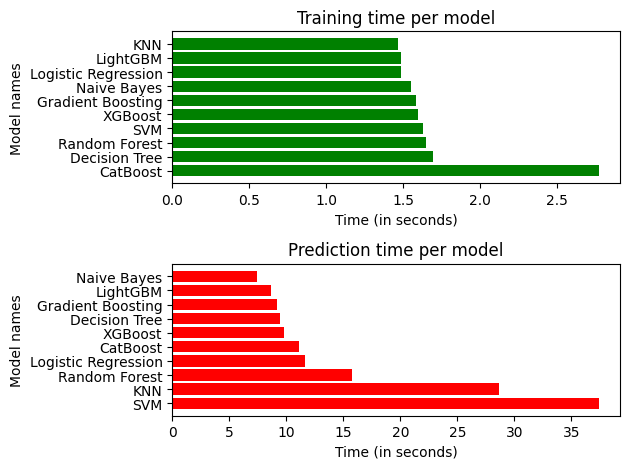

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
def plot_models(model_results):
    fig, ax = plt.subplots(nrows=2, ncols=1)

    # Training:
    results_df = model_results.sort_values('Train Time (s)', ascending=False) # Sorting for the graph

    ax[0].barh(results_df['Model'], results_df['Train Time (s)'], color='green')
    ax[0].set_title('Training time per model')
    ax[0].set_ylabel('Model names')
    ax[0].set_xlabel('Time (in seconds)')

    # Prediction:
    results_df = model_results.sort_values('Pred Time (ms)', ascending=False) # Sorting for the graph again

    ax[1].barh(results_df['Model'], results_df['Pred Time (ms)'], color='red')
    ax[1].set_title('Prediction time per model')
    ax[1].set_ylabel('Model names')
    ax[1].set_xlabel('Time (in seconds)')

    plt.tight_layout()
    plt.show()

plot_models(results_df)

## 9. Filter to Top-Performing Models

Remove models with lower accuracy or poor efficiency:
- Models not achieving perfect/near-perfect accuracy
- Models with excessively long training or prediction times

Retained models: **Logistic Regression, Gradient Boosting, XGBoost**

In [18]:
# List of worst models:
bad_models = ['KNN', 'SVM', 'Decision Tree', 'LightGBM', 'XGBoost', 'Logistic Regression', 'Naive Bayes']
drop_indices = results_df[results_df['Model'].isin(bad_models)].index
new_results = results_df.drop(drop_indices)

print(new_results)

               Model  Accuracy  F1-Score  Precision    Recall  Train Time (s)  \
9           CatBoost     0.976  0.975973   0.975885  0.976080        2.770427   
5  Gradient Boosting     0.976  0.975973   0.975885  0.976080        1.580343   
2      Random Forest     0.928  0.927145   0.938999  0.925287        1.645778   

   Pred Time (ms)   CV_Mean    CV_Std  
9       11.149406  0.968613  0.018001  
5        9.156942  0.968613  0.018001  
2       15.753508  0.968613  0.018001  


## 10. Final Model Comparison Visualization

Compare the top 3 models after hyperparameter tuning to identify the optimal choice based on:
- Perfect or near-perfect accuracy
- Minimal training time
- Fast prediction time

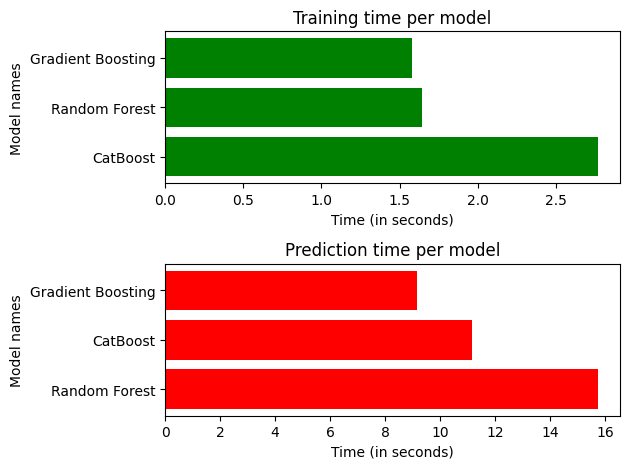

In [19]:
plot_models(new_results)

## 11. Final Model Selection and Evaluation

Select **Gradient Boosting** as the final model based on:
- Excellent cross-validation performance
- Balanced training and prediction times
- Robust to overfitting after hyperparameter tuning

Calculate comprehensive final metrics: accuracy, F1-score, precision, recall.

In [21]:
best_model_name = 'CatBoost'
best_pipeline = tuned_pipelines[best_model_name]

# Final evaluation
y_pred_best = best_pipeline.predict(X_test_raw)
final_accuracy = accuracy_score(y_test, y_pred_best)
final_f1 = f1_score(y_test, y_pred_best, average='macro')
final_precision = precision_score(y_test, y_pred_best, average='macro')
final_recall = recall_score(y_test, y_pred_best, average='macro')

print("\n" + "="*100)
print("Final Model Selection Results")
print("="*100)
print()
print(f"Selected Model: {best_model_name}")
print()
print(f"Performance Metrics:")
print(f"  - Accuracy:  {final_accuracy:.4f}")
print(f"  - F1-Score:  {final_f1:.4f}")
print(f"  - Precision: {final_precision:.4f}")
print(f"  - Recall:    {final_recall:.4f}")
print()


Final Model Selection Results

Selected Model: CatBoost

Performance Metrics:
  - Accuracy:  0.9760
  - F1-Score:  0.9760
  - Precision: 0.9759
  - Recall:    0.9761



In [22]:
import joblib

joblib.dump(best_pipeline, './pipelines/best_mushroom_classifier.joblib')

['./pipelines/best_mushroom_classifier.joblib']